In [ ]:
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

ROOT = Path.cwd()
DATASET_DIR = ROOT / "dataset"
LABELS_FILE = ROOT / "4_1_features_transformation_and_merging.xlsx"
OUTPUT_DIR = ROOT / "resnet152_full_image_output"
PROGRESS_DIR = OUTPUT_DIR / "progress_json"
BACKBONE = "resnet152"
EPOCHS = 5
BATCH_SIZE = 16
LR = 1e-4
IMG_SIZE = 224
TEST_SIZE = 0.1
VAL_SIZE = 0.1
SEED = 42
VAL_COMPUTE_PER_FEATURE_F1 = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

preview_df = pd.read_excel(LABELS_FILE)
print({"rows": int(preview_df.shape[0]), "cols": int(preview_df.shape[1])})
preview_df.head()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
(PROGRESS_DIR / "epochs").mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

{'rows': 8422, 'cols': 147}


In [ ]:
def read_labels_table(path: Path):
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls", ".xlsm"}:
        return pd.read_excel(path)
    if suffix in {".csv", ".txt"}:
        return pd.read_csv(path)


def find_image_column(df: pd.DataFrame):
    lower_to_orig = {str(c).lower(): str(c) for c in df.columns}
    candidates = ["image", "image_name", "filename", "file", "img", "image_id", "name", "path"]
    for c in candidates:
        if c in lower_to_orig:
            return lower_to_orig[c]
    for col in df.columns:
        s = df[col].astype(str).str.lower()
        if s.str.contains(".png", regex=False).any() or s.str.contains(".jpg", regex=False).any() or s.str.contains(".jpeg", regex=False).any():
            return str(col)


def select_target_columns(df: pd.DataFrame, image_col: str):
    blocked_exact = {image_col.lower(), "split", "subset", "set"}
    blocked_partials = ["идентификатор", "identifier", "image", "img", "file", "filename", "path"]
    out = []
    for c in df.columns:
        cl = str(c).lower().strip()
        if cl in blocked_exact:
            continue
        if any(p in cl for p in blocked_partials):
            continue
        out.append(str(c))
    return out


def normalize_value(v):
    if pd.isna(v):
        return "__MISSING__"
    s = str(v).strip()
    if not s:
        return "__MISSING__"
    if s.lower() in {"nan", "none", "null"}:
        return "__MISSING__"
    return s


def infer_feature_type(labels):
    return "binary" if len(labels) <= 2 else "multiclass"


all_png = sorted(p for p in DATASET_DIR.rglob("*") if p.is_file() and p.suffix.lower() == ".png")
by_name = {p.name: p for p in all_png}
by_stem = {}
for p in all_png:
    if p.stem not in by_stem:
        by_stem[p.stem] = p


def resolve_image_path(value: str):
    v = str(value).strip()
    if not v:
        return None
    p = Path(v)
    if p.exists() and p.is_file():
        return p
    name = Path(v).name
    if name in by_name:
        return by_name[name]
    stem = Path(name).stem
    if stem in by_stem:
        return by_stem[stem]
    return None


from feature_lists import full_image_features


df = read_labels_table(LABELS_FILE)
image_col = find_image_column(df)
all_candidate_target_cols = select_target_columns(df, image_col)
allowed_feature_set = set(full_image_features)
target_cols = [c for c in all_candidate_target_cols if c in allowed_feature_set]

print(
    f"Для full-image обучения выбрано признаков из списка: {len(target_cols)} "
    f"(кандидатов до фильтрации: {len(all_candidate_target_cols)})"
)

df = df.dropna(subset=[image_col]).copy()
df["resolved_image"] = df[image_col].apply(resolve_image_path)
df = df[df["resolved_image"].notnull()].copy()

feature_infos_all = {}
for c in target_cols:
    vals = df[c].map(normalize_value)
    labels = sorted(vals.unique().tolist())
    if "__MISSING__" in labels:
        labels = ["__MISSING__"] + [x for x in labels if x != "__MISSING__"]
    label2id = {k: i for i, k in enumerate(labels)}
    id2label = {str(i): k for i, k in enumerate(labels)}
    counts = vals.value_counts(dropna=False).to_dict()
    missing_count = int(counts.get("__MISSING__", 0))
    feature_type = infer_feature_type(labels)
    feature_infos_all[c] = {
        "feature_type": feature_type,
        "num_labels": int(len(labels)),
        "label2id": label2id,
        "id2label": id2label,
        "counts": {str(k): int(v) for k, v in counts.items()},
        "has_missing": "__MISSING__" in label2id,
        "missing_count": missing_count,
    }
    print(
        f"Признак '{c}': тип={feature_type}, классов={len(labels)}, "
        f"есть_пропуски={'да' if '__MISSING__' in label2id else 'нет'}, "
        f"пропусков={missing_count}"
    )

target_cols = [c for c in target_cols if int(feature_infos_all[c]["num_labels"]) >= 2]
excluded_single_label = [c for c, v in feature_infos_all.items() if int(v["num_labels"]) < 2]
feature_infos = {c: feature_infos_all[c] for c in target_cols}
print(
    f"Признаков всего: {len(feature_infos_all)} | "
    f"исключено одно-классовых: {len(excluded_single_label)} | "
    f"итоговых признаков: {len(target_cols)}"
)


def encode_row(row):
    return [int(feature_infos[c]["label2id"][normalize_value(row[c])]) for c in target_cols]


df["encoded_targets"] = df.apply(encode_row, axis=1)

train_df, temp_df = train_test_split(df, test_size=VAL_SIZE + TEST_SIZE, random_state=SEED, shuffle=True)
val_ratio_in_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(temp_df, test_size=1 - val_ratio_in_temp, random_state=SEED, shuffle=True)

feature_class_counts = [int(feature_infos[c]["num_labels"]) for c in target_cols]

feature_schema = {
    "image_column": image_col,
    "target_count": int(len(target_cols)),
    "targets": target_cols,
    "feature_class_counts": feature_class_counts,
    "excluded_single_label_count": int(len(excluded_single_label)),
    "excluded_single_label_features": excluded_single_label,
    "features": feature_infos,
}
with (PROGRESS_DIR / "feature_schema.json").open("w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

split_stats = {
    "total": int(len(df)),
    "train": int(len(train_df)),
    "val": int(len(val_df)),
    "test": int(len(test_df)),
    "targets_count": int(len(target_cols)),
    "targets": target_cols,
}
with (PROGRESS_DIR / "split_stats.json").open("w", encoding="utf-8") as f:
    json.dump(split_stats, f, ensure_ascii=False, indent=2)
split_stats


Для full-image обучения выбрано признаков из списка: 146 (кандидатов до фильтрации: 146)
Признак ''Кусочные', степень выраженности': тип=multiclass, классов=4, есть_пропуски=да, пропусков=5974
Признак ''Промахивающиеся', степень выраженности': тип=multiclass, классов=4, есть_пропуски=да, пропусков=5295
Признак 'Аккуратность рисунка': тип=multiclass, классов=3, есть_пропуски=нет, пропусков=0
Признак 'Аккуратность штриховки (низкая)': тип=binary, классов=2, есть_пропуски=да, пропусков=6468
Признак 'Аккуратность штриховки (средняя (стандарт))': тип=binary, классов=2, есть_пропуски=да, пропусков=6089
Признак 'Возраст обследуемого': тип=multiclass, классов=4, есть_пропуски=нет, пропусков=0
Признак 'Волосы или шапка (аккуратность)': тип=multiclass, классов=3, есть_пропуски=да, пропусков=4619
Признак 'Волосы или шапка (без особенностей)': тип=binary, классов=2, есть_пропуски=да, пропусков=3898
Признак 'Голова (без особенностей)': тип=binary, классов=2, есть_пропуски=да, пропусков=2188
Признак

{'total': 7392,
 'train': 5913,
 'val': 739,
 'test': 740,
 'targets_count': 146,
 'targets': ["'Кусочные', степень выраженности",
  "'Промахивающиеся', степень выраженности",
  'Аккуратность рисунка',
  'Аккуратность штриховки (низкая)',
  'Аккуратность штриховки (средняя (стандарт))',
  'Возраст обследуемого',
  'Волосы или шапка (аккуратность)',
  'Волосы или шапка (без особенностей)',
  'Голова (без особенностей)',
  'Голова (искажена форма)',
  'Голова (размер)',
  'Грубые нарушения рисунка (нарушение пропорций)',
  'Грубые нарушения рисунка (отклонение от вертикали)',
  'Грубые нарушения рисунка (отсутствуют)',
  'Два глаза одинаковые',
  'Детали (лицо) (волосы (шапка))',
  'Детали (лицо) (глаза (один или оба))',
  'Детали (лицо) (другое)',
  'Детали (лицо) (лоб)',
  'Детали (лицо) (нос)',
  'Детали (лицо) (рот)',
  'Детали (лицо) (уши)',
  'Детализированность',
  'Дополнительно (в руке или рядом) (дополнительные предметы отсутствуют)',
  'Дополнительные детали изображения фигуры

In [ ]:
def build_split_records(split_name: str, split_df: pd.DataFrame):
    records = []
    dropped_missing = 0
    total_items = int(len(split_df))
    for i, row in split_df.reset_index(drop=True).iterrows():
        src = Path(row["resolved_image"])
        if not src.exists() or src.stat().st_size == 0:
            dropped_missing += 1
        else:
            records.append({"image": str(src.resolve()), "target": [int(v) for v in row["encoded_targets"]]})
        processed = i + 1
        if processed % 100 == 0 or processed == total_items:
            print(
                f"Сплит '{split_name}': обработано {processed}/{total_items}, "
                f"сохранено={len(records)}, пропущено_битых={dropped_missing}"
            )
    report = {
        "split": split_name,
        "kept_full_image": len(records),
        "dropped_missing": dropped_missing,
        "image_mode": "full",
    }
    with (PROGRESS_DIR / f"records_report_{split_name}.json").open("w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)
    with (OUTPUT_DIR / f"{split_name}_records.json").open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)
    return records, report


train_records, train_report = build_split_records("train", train_df)
val_records, val_report = build_split_records("val", val_df)
test_records, test_report = build_split_records("test", test_df)

{"train": train_report, "val": val_report, "test": test_report}


Сплит 'train': обработано 100/5913, сохранено=100, пропущено_битых=0
Сплит 'train': обработано 200/5913, сохранено=200, пропущено_битых=0
Сплит 'train': обработано 300/5913, сохранено=300, пропущено_битых=0
Сплит 'train': обработано 400/5913, сохранено=400, пропущено_битых=0
Сплит 'train': обработано 500/5913, сохранено=500, пропущено_битых=0
Сплит 'train': обработано 600/5913, сохранено=600, пропущено_битых=0
Сплит 'train': обработано 700/5913, сохранено=700, пропущено_битых=0
Сплит 'train': обработано 800/5913, сохранено=800, пропущено_битых=0
Сплит 'train': обработано 900/5913, сохранено=900, пропущено_битых=0
Сплит 'train': обработано 1000/5913, сохранено=1000, пропущено_битых=0
Сплит 'train': обработано 1100/5913, сохранено=1100, пропущено_битых=0
Сплит 'train': обработано 1200/5913, сохранено=1200, пропущено_битых=0
Сплит 'train': обработано 1300/5913, сохранено=1300, пропущено_битых=0
Сплит 'train': обработано 1400/5913, сохранено=1400, пропущено_битых=0
Сплит 'train': обработан

{'train': {'split': 'train',
  'kept_full_image': 5913,
  'dropped_missing': 0,
  'image_mode': 'full'},
 'val': {'split': 'val',
  'kept_full_image': 739,
  'dropped_missing': 0,
  'image_mode': 'full'},
 'test': {'split': 'test',
  'kept_full_image': 740,
  'dropped_missing': 0,
  'image_mode': 'full'}}

In [ ]:
class MultiTaskImageDataset(Dataset):
    def __init__(self, records, transform, split_name):
        self.records = [r for r in records if Path(r["image"]).exists()]
        self.transform = transform
        dropped = int(len(records) - len(self.records))
        if dropped > 0:
            print(f"Сплит '{split_name}': пропущено отсутствующих файлов={dropped}, оставлено={len(self.records)}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["image"]).convert("RGB")
        x = self.transform(img)
        y = torch.tensor(rec["target"], dtype=torch.long)
        return x, y


class ResNetMultiHead(nn.Module):
    def __init__(self, class_counts, backbone_name):
        super().__init__()
        if backbone_name == "resnet152":
            backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        elif backbone_name == "resnet101":
            backbone = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.heads = nn.ModuleList([nn.Linear(in_features, int(c)) for c in class_counts])

    def forward(self, x):
        feat = self.backbone(x)
        return [head(feat) for head in self.heads]


train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = MultiTaskImageDataset(train_records, train_tf, "train")
val_ds = MultiTaskImageDataset(val_records, eval_tf, "val")
test_ds = MultiTaskImageDataset(test_records, eval_tf, "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = ResNetMultiHead(feature_class_counts, BACKBONE).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [5]:
def epoch_pass(loader, model, optimizer=None, epoch=0, mode="train"):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    total_count = 0
    acc_sum = 0.0
    pbar = tqdm(loader, desc=f"{mode} {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits_list = model(x)
        losses = []
        pred_list = []
        for i, logits in enumerate(logits_list):
            yi = y[:, i]
            losses.append(nn.functional.cross_entropy(logits, yi))
            pred_list.append(logits.argmax(dim=1))
        loss = torch.stack(losses).mean()
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            per_feature_acc = torch.stack([(pred_list[i] == y[:, i]).float().mean() for i in range(len(pred_list))])
            batch_acc = per_feature_acc.mean().item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{batch_acc:.4f}"})
        bsz = x.size(0)
        total_loss += loss.item() * bsz
        acc_sum += batch_acc * bsz
        total_count += bsz
    return total_loss / total_count, acc_sum / total_count


def evaluate_f1(loader, model, per_feature=False):
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits_list = model(x)
            preds = torch.stack([logits.argmax(dim=1) for logits in logits_list], dim=1).cpu().numpy().astype(np.int32)
            all_pred.append(preds)
            all_true.append(y.numpy().astype(np.int32))
    y_true = np.vstack(all_true)
    y_pred = np.vstack(all_pred)
    flat_true = y_true.reshape(-1)
    flat_pred = y_pred.reshape(-1)
    out = {
        "f1_micro": float(f1_score(flat_true, flat_pred, average="micro", zero_division=0)),
        "f1_macro": float(f1_score(flat_true, flat_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(flat_true, flat_pred, average="weighted", zero_division=0)),
    }
    if per_feature:
        out["f1_per_feature_macro"] = {
            k: float(f1_score(y_true[:, i], y_pred[:, i], average="macro", zero_division=0))
            for i, k in enumerate(target_cols)
        }
    return out


history = []
for epoch in tqdm(range(1, EPOCHS + 1), desc="epochs"):
    t0 = time.time()
    train_loss, train_acc = epoch_pass(train_loader, model, optimizer, epoch=epoch, mode="train")
    val_loss, val_acc = epoch_pass(val_loader, model, optimizer=None, epoch=epoch, mode="val")
    val_f1 = evaluate_f1(val_loader, model, per_feature=VAL_COMPUTE_PER_FEATURE_F1)
    rec = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "val_f1_micro": float(val_f1["f1_micro"]),
        "val_f1_macro": float(val_f1["f1_macro"]),
        "val_f1_weighted": float(val_f1["f1_weighted"]),
        "seconds": float(time.time() - t0),
    }
    if VAL_COMPUTE_PER_FEATURE_F1:
        rec["val_f1_per_feature_macro"] = val_f1["f1_per_feature_macro"]
    history.append(rec)
    print(
        f"Эпоха {epoch}: train_loss={rec['train_loss']:.4f}, val_loss={rec['val_loss']:.4f}, "
        f"train_acc={rec['train_accuracy']:.4f}, val_acc={rec['val_accuracy']:.4f}, "
        f"val_f1_macro={rec['val_f1_macro']:.4f}, время={rec['seconds']:.1f}с"
    )
    with (PROGRESS_DIR / "epochs" / f"epoch_{epoch:03d}.json").open("w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False, indent=2)
    with (PROGRESS_DIR / "history.json").open("w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

torch.save({
    "backbone": BACKBONE,
    "model_state_dict": model.state_dict(),
    "target_cols": target_cols,
    "feature_class_counts": feature_class_counts,
    "feature_infos": feature_infos,
}, OUTPUT_DIR / "resnet152_full_image_multitask.pth")
history_df = pd.DataFrame(history)
history_df


epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train 1/5:   0%|          | 0/370 [00:00<?, ?it/s]

val 1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 1: train_loss=0.4655, val_loss=0.4228, train_acc=0.8095, val_acc=0.8275, val_f1_macro=0.7462, время=1151.1с


train 2/5:   0%|          | 0/370 [00:00<?, ?it/s]

...

Эпоха 4: train_loss=0.3612, val_loss=0.3789, train_acc=0.8522, val_acc=0.8468, val_f1_macro=0.7679, время=1101.2с


train 5/5:   0%|          | 0/370 [00:00<?, ?it/s]

val 5/5:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 5: train_loss=0.3413, val_loss=0.3768, train_acc=0.8605, val_acc=0.8488, val_f1_macro=0.7716, время=1119.0с


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_f1_micro,val_f1_macro,val_f1_weighted,seconds
0,1,0.465457,0.809455,0.422763,0.827488,0.827488,0.746150,0.821201,1151.128561
1,2,0.407459,0.833280,0.398229,0.838731,0.838731,0.758954,0.834384,1138.483561
2,3,0.382711,0.843533,0.385812,0.842781,0.842781,0.762689,0.838517,1106.767023
3,4,0.361232,0.852197,0.378869,0.846822,0.846822,0.767927,0.843918,1101.215771
4,5,0.341305,0.860537,0.376778,0.848759,0.848759,0.771642,0.846262,1119.011597


'E:\\SosedTemporary\\WorkingSpace\\Narabotki\\26-05-18_1\\resnet152_full_image_output\\training_curves.png'

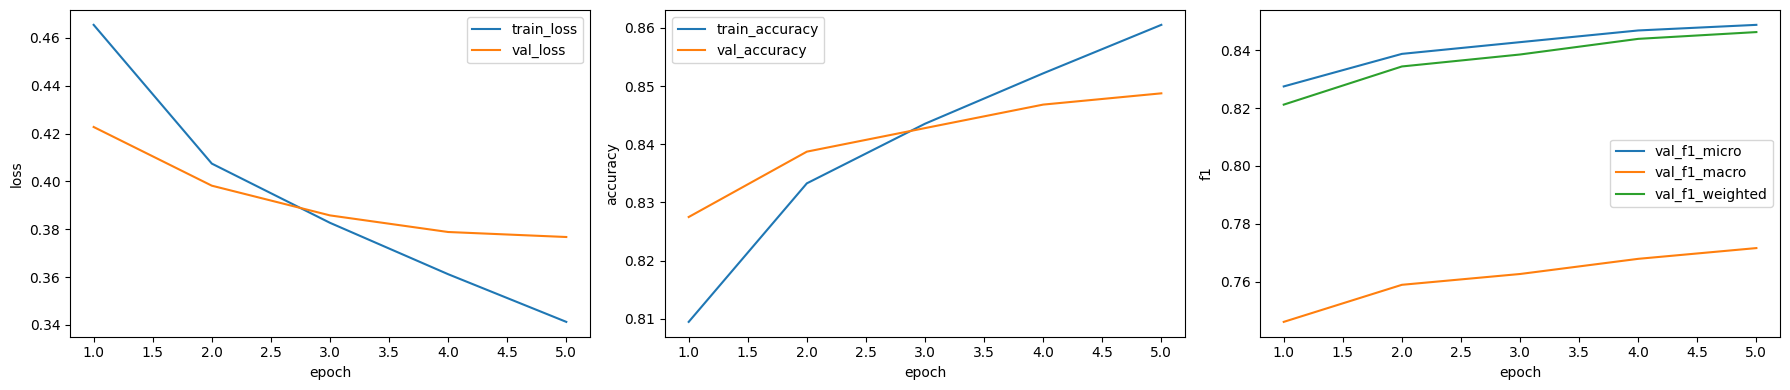

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

f1_metrics = ["val_f1_micro", "val_f1_macro", "val_f1_weighted"]
for metric_name in f1_metrics:
    if metric_name in history_df.columns:
        axes[2].plot(history_df["epoch"], history_df[metric_name], label=metric_name)
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("f1")
axes[2].legend()

plot_path = OUTPUT_DIR / "training_curves.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150)
str(plot_path.resolve())


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import f1_score

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "resnet152_full_image_output"
CKPT_PATH = OUTPUT_DIR / "resnet152_full_image_multitask.pth"
TEST_RECORDS_PATH = OUTPUT_DIR / "test_records.json"
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(CKPT_PATH, map_location="cpu")
target_cols = ckpt["target_cols"]
feature_class_counts = ckpt["feature_class_counts"]

class ResNetMultiHead(nn.Module):
    def __init__(self, class_counts):
        super().__init__()
        backbone = models.resnet152(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.heads = nn.ModuleList([nn.Linear(in_features, int(c)) for c in class_counts])

    def forward(self, x):
        feat = self.backbone(x)
        return [head(feat) for head in self.heads]

model = ResNetMultiHead(feature_class_counts)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE)
model.eval()

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

records = json.loads(TEST_RECORDS_PATH.read_text(encoding="utf-8"))
records = [r for r in records if Path(r["image"]).exists()]

class MultiTaskImageDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["image"]).convert("RGB")
        x = self.transform(img)
        y = torch.tensor(rec["target"], dtype=torch.long)
        return x, y

test_ds = MultiTaskImageDataset(records, eval_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_true = []
all_pred = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits_list = model(x)
        preds = torch.stack([logits.argmax(dim=1) for logits in logits_list], dim=1).cpu().numpy().astype(np.int32)
        all_pred.append(preds)
        all_true.append(y.numpy().astype(np.int32))

y_true = np.vstack(all_true)
y_pred = np.vstack(all_pred)

flat_true = y_true.reshape(-1)
flat_pred = y_pred.reshape(-1)
f1_micro = f1_score(flat_true, flat_pred, average="micro", zero_division=0)
f1_macro = f1_score(flat_true, flat_pred, average="macro", zero_division=0)
f1_weighted = f1_score(flat_true, flat_pred, average="weighted", zero_division=0)

f1_per_feature_micro = [f1_score(y_true[:, i], y_pred[:, i], average="micro", zero_division=0) for i in range(y_true.shape[1])]
f1_per_feature_macro = [f1_score(y_true[:, i], y_pred[:, i], average="macro", zero_division=0) for i in range(y_true.shape[1])]
f1_per_feature_weighted = [f1_score(y_true[:, i], y_pred[:, i], average="weighted", zero_division=0) for i in range(y_true.shape[1])]

summary_df = pd.DataFrame([
    {"metric": "f1_micro", "value": float(f1_micro)},
    {"metric": "f1_macro", "value": float(f1_macro)},
    {"metric": "f1_weighted", "value": float(f1_weighted)},
])
per_feature_df = pd.DataFrame({
    "feature": target_cols,
    "num_labels": feature_class_counts,
    "f1_micro": f1_per_feature_micro,
    "f1_macro": f1_per_feature_macro,
    "f1_weighted": f1_per_feature_weighted,
})

xlsx_path = OUTPUT_DIR / "test_f1_metrics.xlsx"
with pd.ExcelWriter(xlsx_path) as writer:
    summary_df.to_excel(writer, index=False, sheet_name="summary")
    per_feature_df.to_excel(writer, index=False, sheet_name="per_feature")

f1_json = {
    "f1_micro": float(f1_micro),
    "f1_macro": float(f1_macro),
    "f1_weighted": float(f1_weighted),
    "per_feature_f1_micro": {k: float(v) for k, v in zip(target_cols, f1_per_feature_micro)},
    "per_feature_f1_macro": {k: float(v) for k, v in zip(target_cols, f1_per_feature_macro)},
    "per_feature_f1_weighted": {k: float(v) for k, v in zip(target_cols, f1_per_feature_weighted)},
}
with (OUTPUT_DIR / "test_f1_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(f1_json, f, ensure_ascii=False, indent=2)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from IPython.display import display

pd.set_option("display.colheader_justify", "left")

def _left(df):
    return df.style.set_properties(**{"text-align": "left"}).set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
    ])

display(_left(summary_df))
display(_left(per_feature_df))



,metric,value
0,f1_micro,0.850250
1,f1_macro,0.779826
2,f1_weighted,0.847778


,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,"'Кусочные', степень выраженности",4,0.817568,0.253665,0.743259
1,"'Промахивающиеся', степень выраженности",4,0.717568,0.234190,0.629094
2,Аккуратность рисунка,3,0.645946,0.525607,0.611501
3,Аккуратность штриховки (низкая),2,0.874324,0.581486,0.838843
4,Аккуратность штриховки (средняя (стандарт)),2,0.824324,0.588889,0.792372
5,Возраст обследуемого,4,0.594595,0.572765,0.582513
6,Волосы или шапка (аккуратность),3,0.644595,0.478570,0.607571
7,Волосы или шапка (без особенностей),2,0.671622,0.671573,0.671832
8,Голова (без особенностей),2,0.795946,0.722343,0.776048
9,Голова (искажена форма),2,0.951351,0.487535,0.927633


## H. Stable features export

In [8]:
def export_stable_features(per_feature_df: pd.DataFrame, thresholds=(0.7, 0.8, 0.9)):
    per_feature_xlsx_path = OUTPUT_DIR / "per_feature_f1_table.xlsx"

    for threshold in thresholds:
        stable_df = per_feature_df.loc[
            per_feature_df["f1_macro"].astype(float) >= float(threshold)
        ].reset_index(drop=True)

        display(_left(stable_df))

        with pd.ExcelWriter(per_feature_xlsx_path) as writer:
            per_feature_df.to_excel(writer, index=False, sheet_name="per_feature")
            stable_df.to_excel(writer, index=False, sheet_name="macro_ge_threshold")

        stable_export_path = OUTPUT_DIR / f"per_feature_macro_ge_{threshold:.2f}.xlsx"
        stable_df.to_excel(stable_export_path, index=False, sheet_name="macro_ge_threshold")


export_stable_features(per_feature_df)

,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,Голова (без особенностей),2,0.795946,0.722343,0.776048
1,Детали (лицо) (волосы (шапка)),2,0.929730,0.838634,0.927436
2,Детали (лицо) (глаза (один или оба)),2,0.979730,0.863150,0.977511
3,Детали (лицо) (рот),2,0.960811,0.791064,0.955466
4,Дополнительные детали изображения фигуры (отсутствуют),2,0.791892,0.787861,0.793156
5,Дополнительные детали изображения фигуры (пуговицы),2,0.967568,0.791549,0.966532
6,Дополнительные детали изображения фигуры (украшения),2,0.855405,0.794440,0.856767
7,Кисть (отсутствует),2,0.760811,0.758588,0.761343
8,Кисть (средняя (стандарт)),2,0.748649,0.741387,0.746775
9,"Ладонь, пальцы (изображены пальцы)",2,0.827027,0.826901,0.827191


,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,Детали (лицо) (волосы (шапка)),2,0.929730,0.838634,0.927436
1,Детали (лицо) (глаза (один или оба)),2,0.979730,0.863150,0.977511
2,"Ладонь, пальцы (изображены пальцы)",2,0.827027,0.826901,0.827191
3,"Ладонь, пальцы (отсутствуют)",2,0.868919,0.856083,0.869558
4,Одежда (реалистичное изображение),2,0.841892,0.811533,0.841585
5,Пальцы (изображены черточками),2,0.950000,0.806953,0.946182
6,Пол обследуемого,2,0.837838,0.837780,0.837738
7,Положение рук (вытянуты в стороны или вперед),2,0.939189,0.808927,0.935138
8,Положение рук (дополнительно),2,0.945946,0.844207,0.944245
9,Положение рук (за спиной или в карманах),2,0.958108,0.853862,0.956607


,feature,num_labels,f1_micro,f1_macro,f1_weighted
